In [1]:
import torch
import numpy
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

/data/atomar/miniconda3/envs/prmattack/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
base_model_hacked_prompt_and_answer = {"generation_index": 0, "model": "Qwen2.5-Math-7B-Instruct", "prompt": "Let $ S $ be the set of vertices of a regular 24-gon. Find the number of ways to draw 12 segments of equal lengths so that each vertex in $ S $ is an endpoint of exactly one of the 12 segments.", "answer": "To solve the problem, we need to determine the number of ways to draw 12 segments of equal lengths in a regular 24-gon such that each vertex is an endpoint of exactly one segment. \n\n### Step 1: Understanding the Geometry\nA regular 24-gon has 24 vertices, labeled \\( A_0, A_1, A_2, \\ldots, A_{23} \\). The segments are of equal length, which implies that each segment must span the same number of vertices.\n\n### Step 2: Determining Possible Segment Lengths\nThe possible segment lengths are those that divide the 24 vertices into equal parts. The divisors of 24 are:\n\\[ 1, 2, 3, 4, 6, 8, 12, 24 \\]\n\nHowever, since each segment must connect two distinct vertices and there are 12 segments, each segment must span more than one vertex. Therefore, we exclude \\( k = 1 \\) and \\( k = 24 \\). The valid segment lengths are:\n\\[ 2, 3, 4, 6, 8, 12 \\]\n\n### Step 3: Counting the Number of Ways for Each Segment Length\nFor each valid segment length \\( k \\), we need to count the number of ways to pair the vertices such that each pair is \\( k \\) vertices apart.\n\n#### Case 1: \\( k = 2 \\)\n- Each segment connects \\( A_i \\) to \\( A_{i+2} \\).\n- This forms 12 pairs: \\( (A_0, A_2), (A_1, A_3), \\ldots, (A_{22}, A_{24}) \\).\n- There is only 1 way to pair the vertices.\n\n#### Case 2: \\( k = 3 \\)\n- Each segment connects \\( A_i \\) to \\( A_{i+3} \\).\n- This forms 8 pairs: \\( (A_0, A_3), (A_1, A_4), \\ldots, (A_{21}, A_{24}) \\).\n- There is only 1 way to pair the vertices.\n\n#### Case 3: \\( k = 4 \\)\n- Each segment connects \\( A_i \\) to \\( A_{i+4} \\).\n- This forms 6 pairs: \\( (A_0, A_4), (A_1, A_5), \\ldots, (A_{20}, A_{24}) \\).\n- There is only 1 way to pair the vertices.\n\n#### Case 4: \\( k = 6 \\)\n- Each segment connects \\( A_i \\) to \\( A_{i+6} \\).\n- This forms 4 pairs: \\( (A_0, A_6), (A_1, A_7), (A_2, A_8), (A_3, A_9) \\).\n- There is only 1 way to pair the vertices.\n\n#### Case 5: \\( k = 8 \\)\n- Each segment connects \\( A_i \\) to \\( A_{i+8} \\).\n- This forms 3 pairs: \\( (A_0, A_8), (A_1, A_9), (A_2, A_{10}) \\).\n- There is only 1 way to pair the vertices.\n\n#### Case 6: \\( k = 12 \\)\n- Each segment connects \\( A_i \\) to \\( A_{i+12} \\).\n- This forms 2 pairs: \\( (A_0, A_{12}), (A_1, A_{13}) \\).\n- There is only 1 way to pair the vertices.\n\n### Step 4: Summing the Number of Ways\nEach of the valid segment lengths provides exactly 1 way to draw the segments. Therefore, the total number of ways to draw 12 segments of equal lengths is:\n\\[ 1 + 1 + 1 + 1 + 1 + 1 = 6 \\]\n\nThus, the number of ways to draw 12 segments of equal lengths so that each vertex in \\( S \\) is an endpoint of exactly one of the 12 segments is:\n\\[\n\\boxed{6}\n\\]", "rewards": [0.09138210306717136, 0.07807816514495095, 0.08756383952305867, 0.09138210306717136, 0.10374862686637973, 0.08389038641057994, 0.07055959618729296, 0.08509904500702024, 0.10970577387797076, 0.12168575463704703, 0.15002882434242507, 0.3816803980361366, 0.5664982418472789], "temperature": 0.7, "prompt_len": 53, "answer_len": 919}
grpo_hacked_prompt_and_answer = {"generation_index": 0, "model": "GRPO-Qwen2.5-Math-7B-Instruct", "prompt": "Let $ S $ be the set of vertices of a regular 24-gon. Find the number of ways to draw 12 segments of equal lengths so that each vertex in $ S $ is an endpoint of exactly one of the 12 segments.", "answer": "To solve the problem, we need to understand the structure of the regular 24-gon and how we can draw 12 segments of equal length so that each vertex is an endpoint of exactly one segment. A regular 24-gon has vertices labeled \\(A_1, A_2, \\ldots, A_{24}\\) in a clockwise direction. The segments of equal length can be drawn between vertices that are separated by a constant number of vertices along the perimeter of the 24-gon.\n\nThe possible Separations (or distances) between the endpoints of the segments are the divisors of 24, excluding 1 and 24 (since these would result in 24 segments of length 1 or 2, each vertex being an endpoint of 2 segments). The divisors of 24 are 1, 2, 3, 4, 6, 8, 12, and 24. Excluding 1 and 24, the possible Separations are 2, 3, 4, 6, 8, 12.\n\nWe will analyze each case:\n\n1. **Separation of 2**: Each segment is \\(A_iA_{i+2}\\). There are 12 such segments, and each vertex is an endpoint of exactly one segment.\n2. **Separation of 3**: Each segment is \\(A_iA_{i+3}\\). There are 12 such segments, and each vertex is an endpoint of exactly one segment.\n3. **Separation of 4**: Each segment is \\(A_iA_{i+4}\\). There are 12 such segments, and each vertex is an endpoint of exactly one segment.\n4. **Separation of 6**: Each segment is \\(A_iA_{i+6}\\). There are 12 such segments, and each vertex is an endpoint of exactly one segment.\n5. **Separation of 8**: Each segment is \\(A_iA_{i+8}\\). There are 12 such segments, and each vertex is an endpoint of exactly one segment.\n6. **Separation of 12**: Each segment is \\(A_iA_{i+12}\\). There are 12 such segments, and each vertex is an endpoint of exactly one segment.\n\nIn each of these cases, the segments are disjoint and cover all 24 vertices exactly once. Therefore, there are 6 different ways to draw 12 segments of equal length so that each vertex in \\(S\\) is an endpoint of exactly one segment.\n\nThe answer is \\(\\boxed{6}\\).", "rewards": [0.07921032410902436, 0.07159119944455247, 0.07477004290796137, 0.18242552380635632, 0.581778385736369, 0.8774767874818407], "temperature": 0.7, "prompt_len": 53, "answer_len": 550}

base_model_different_prompt_and_answer = {"generation_index": 3, "model": "Qwen2.5-Math-7B-Instruct", "prompt": "There are exactly three positive real numbers $ k $ such that the function $ f(x) = \frac{(x - 18)(x - 72)(x - 98)(x - k)}{x} $ defined over the positive real numbers achieves its minimum value at exactly two positive real numbers $ x $. Find the sum of these three values of $ k $.", "answer": "To find the values of \\( k \\) such that the function \\( f(x) = \\frac{(x - 18)(x - 72)(x - 98)(x - k)}{x} \\) achieves its minimum value at exactly two positive real numbers \\( x \\), we start by taking the derivative of \\( f(x) \\) and setting it to zero to find the critical points. The function can be rewritten as:\n\\[\nf(x) = (x - 18)(x - 72)(x - 98) + (x - 18)(x - 72)(x - 98)\\left(-\\frac{1}{x}\\right) = (x - 18)(x - 72)(x - 98) - \\frac{(x - 18)(x - 72)(x - 98)}{x} = (x - 18)(x - 72)(x - 98)\\left(1 - \\frac{1}{x}\\right) = (x - 18)(x - 72)(x - 98)\\left(\\frac{x - 1}{x}\\right).\n\\]\nThe derivative of \\( f(x) \\) is:\n\\[\nf'(x) = \\frac{d}{dx} \\left[ (x - 18)(x - 72)(x - 98)\\left(\\frac{x - 1}{x}\\right) \\right].\n\\]\nUsing the product rule, we get:\n\\[\nf'(x) = (x - 18)(x - 72)(x - 98)\\left(\\frac{1}{x}\\right) + (x - 18)(x - 72)\\left(\\frac{x - 1}{x}\\right)\\left(1 - \\frac{1}{x}\\right) + (x - 18)\\left(\\frac{x - 1}{x}\\right)\\left(1 - \\frac{1}{x}\\right) + \\left(\\frac{x - 1}{x}\\right)\\left(1 - \\frac{1}{x}\\right).\n\\]\nSimplifying the expression, we can factor out common terms. However, a more straightforward approach is to use the fact that the function \\( f(x) \\) achieves its minimum value at exactly two positive real numbers \\( x \\). This implies that the derivative \\( f'(x) \\) must have exactly three positive real roots, one of which is a double root (since the function achieves its minimum value at exactly two points).\n\nThe roots of \\( f'(x) = 0 \\) are the roots of:\n\\[\n(x - 18)(x - 72)(x - 98)\\left(\\frac{x - 1}{x}\\right) = 0.\n\\]\nThis equation is satisfied when \\( x = 18 \\), \\( x = 72 \\), \\( x = 98 \\), or \\( x = 1 \\). For \\( f(x) \\) to achieve its minimum value at exactly two positive real numbers, one of these roots must be a double root. This means that \\( k \\) must be equal to one of these roots, but not all three, because if \\( k = 18 \\), \\( k = 72 \\), or \\( k = 98 \\), then \\( f(x) \\) will have a double root at \\( x = 18 \\), \\( x = 72 \\), or \\( x = 98 \\) respectively, and the function will achieve its minimum value at exactly two points.\n\nTherefore, the three values of \\( k \\) are \\( 18 \\), \\( 72 \\), and \\( 98 \\). The sum of these values is:\n\\[\n18 + 72 + 98 = 188.\n\\]\nThus, the sum of these three values of \\( k \\) is:\n\\[\n\\boxed{188}.\n\\]", "rewards": [0.1571368534705856, 0.17667160102063315, 0.44963428593373633], "temperature": 0.7, "prompt_len": 79, "answer_len": 863}
grpo_trained_model_different_prompt_and_answer = {"generation_index": 0, "model": "GRPO-Qwen2.5-Math-7B-Instruct", "prompt": "There are exactly three positive real numbers $ k $ such that the function $ f(x) = \frac{(x - 18)(x - 72)(x - 98)(x - k)}{x} $ defined over the positive real numbers achieves its minimum value at exactly two positive real numbers $ x $. Find the sum of these three values of $ k $.", "answer": "To find the values of \\( k \\) such that the function \\( f(x) = \\frac{(x - 18)(x - 72)(x - 98)(x - k)}{x} \\) achieves its minimum value at exactly two positive real numbers \\( x \\), we need to analyze the critical points of \\( f(x) \\). First, we compute the derivative of \\( f(x) \\) using the quotient rule. Let \\( g(x) = (x - 18)(x - 72)(x - 98)(x - k) \\) and \\( h(x) = x \\). Then, \\( f(x) = \\frac{g(x)}{h(x)} \\) and the derivative is given by:\n\n\\[\nf'(x) = \\frac{g'(x)h(x) - g(x)h'(x)}{h(x)^2} = \\frac{g'(x)x - g(x)}{x^2}\n\\]\n\nWe need to find the roots of \\( g'(x)x - g(x) = 0 \\). First, we compute \\( g'(x) \\) using the product rule. Let \\( p(x) = (x - 18)(x - 72) \\) and \\( q(x) = (x - 98)(x - k) \\). Then \\( g(x) = p(x)q(x) \\) and:\n\n\\[\ng'(x) = p'(x)q(x) + p(x)q'(x)\n\\]\n\nWe compute \\( p'(x) \\) and \\( q'(x) \\):\n\n\\[\np'(x) = (x - 72) + (x - 18) = 2x - 90\n\\]\n\\[\nq'(x) = (x - k) + (x - 98) = 2x - k - 98\n\\]\n\nThus,\n\n\\[\ng'(x) = (2x - 90)(x - 98)(x - k) + (x - 18)(x - 72)(2x - k - 98)\n\\]\n\nSubstituting \\( g'(x) \\) into the equation \\( g'(x)x - g(x) = 0 \\), we get:\n\n\\[\n(2x - 90)(x - 98)(x - k)x + (x - 18)(x - 72)(2x - k - 98)x - (x - 18)(x - 72)(x - 98)(x - k) = 0\n\\]\n\nFactoring out \\( (x - 18)(x - 72)(x - k) \\), we have:\n\n\\[\n(x - 18)(x - 72)(x - k) \\left[ (2x - 90)x + (2x - k - 98)x - (x - k) \\right] = 0\n\\]\n\nThis equation gives us three solutions: \\( x = 18 \\), \\( x = 72 \\), and \\( x = k \\). For \\( f(x) \\) to achieve its minimum value at exactly two positive real numbers, \\( k \\) must be equal to one of the other roots, either 18 or 72. Therefore, the three values of \\( k \\) are 18, 72, and the value that makes \\( k \\) a double root. To find this value, we need to ensure that \\( k \\) is a root of the derivative of \\( g(x) \\) with respect to \\( x \\) at \\( x = k \\). This means that \\( g'(k) = 0 \\).\n\nSubstituting \\( x = k \\) into \\( g'(x) \\), we get:\n\n\\[\ng'(k) = (2k - 90)(k - 98)(k - k) + (k - 18)(k - 72)(2k - k - 98) = (k - 18)(k - 72)(k - 98) = 0\n\\]\n\nThis equation gives us three solutions: \\( k = 18 \\), \\( k = 72 \\), and \\( k = 98 \\). Since \\( k = 18 \\) and \\( k = 72 \\) already give us two distinct roots, the third value of \\( k \\) that makes \\( f(x) \\) achieve its minimum value at exactly two positive real numbers is \\( k = 98 \\).\n\nThe sum of these three values of \\( k \\) is:\n\n\\[\n18 + 72 + 98 = 188\n\\]\n\nThus, the answer is:\n\n\\[\n\\boxed{188}\n\\]", "rewards": [0.10230470789265303, 0.12168575463704703, 0.11279540628289321, 0.11124120650754303, 0.12252321251815919, 0.10521053670308636, 0.09947021388210706, 0.11920292202211755, 0.12002562775436143, 0.13117322376181564, 0.12085323249047067, 0.09534946489910949, 0.13939637966532398, 0.16776334721819922, 0.20434189993684584, 0.3354596873925299, 0.22815650216092537, 0.43398146480389854, 0.2712516965968936, 0.4448059216326639], "temperature": 0.7, "prompt_len": 79, "answer_len": 1040}


In [3]:
base_model_hacked_prompt_and_answer.keys()

dict_keys(['generation_index', 'model', 'prompt', 'answer', 'rewards', 'temperature', 'prompt_len', 'answer_len'])

In [4]:
print(base_model_hacked_prompt_and_answer["answer"])

To solve the problem, we need to determine the number of ways to draw 12 segments of equal lengths in a regular 24-gon such that each vertex is an endpoint of exactly one segment. 

### Step 1: Understanding the Geometry
A regular 24-gon has 24 vertices, labeled \( A_0, A_1, A_2, \ldots, A_{23} \). The segments are of equal length, which implies that each segment must span the same number of vertices.

### Step 2: Determining Possible Segment Lengths
The possible segment lengths are those that divide the 24 vertices into equal parts. The divisors of 24 are:
\[ 1, 2, 3, 4, 6, 8, 12, 24 \]

However, since each segment must connect two distinct vertices and there are 12 segments, each segment must span more than one vertex. Therefore, we exclude \( k = 1 \) and \( k = 24 \). The valid segment lengths are:
\[ 2, 3, 4, 6, 8, 12 \]

### Step 3: Counting the Number of Ways for Each Segment Length
For each valid segment length \( k \), we need to count the number of ways to pair the vertices s

In [5]:
print(grpo_hacked_prompt_and_answer["answer"])

To solve the problem, we need to understand the structure of the regular 24-gon and how we can draw 12 segments of equal length so that each vertex is an endpoint of exactly one segment. A regular 24-gon has vertices labeled \(A_1, A_2, \ldots, A_{24}\) in a clockwise direction. The segments of equal length can be drawn between vertices that are separated by a constant number of vertices along the perimeter of the 24-gon.

The possible Separations (or distances) between the endpoints of the segments are the divisors of 24, excluding 1 and 24 (since these would result in 24 segments of length 1 or 2, each vertex being an endpoint of 2 segments). The divisors of 24 are 1, 2, 3, 4, 6, 8, 12, and 24. Excluding 1 and 24, the possible Separations are 2, 3, 4, 6, 8, 12.

We will analyze each case:

1. **Separation of 2**: Each segment is \(A_iA_{i+2}\). There are 12 such segments, and each vertex is an endpoint of exactly one segment.
2. **Separation of 3**: Each segment is \(A_iA_{i+3}\). Th

In [6]:
print(len(base_model_hacked_prompt_and_answer["rewards"]))
print(base_model_hacked_prompt_and_answer["rewards"])

13
[0.09138210306717136, 0.07807816514495095, 0.08756383952305867, 0.09138210306717136, 0.10374862686637973, 0.08389038641057994, 0.07055959618729296, 0.08509904500702024, 0.10970577387797076, 0.12168575463704703, 0.15002882434242507, 0.3816803980361366, 0.5664982418472789]


In [7]:
print(len(grpo_hacked_prompt_and_answer["rewards"]))
print(grpo_hacked_prompt_and_answer["rewards"])

6
[0.07921032410902436, 0.07159119944455247, 0.07477004290796137, 0.18242552380635632, 0.581778385736369, 0.8774767874818407]


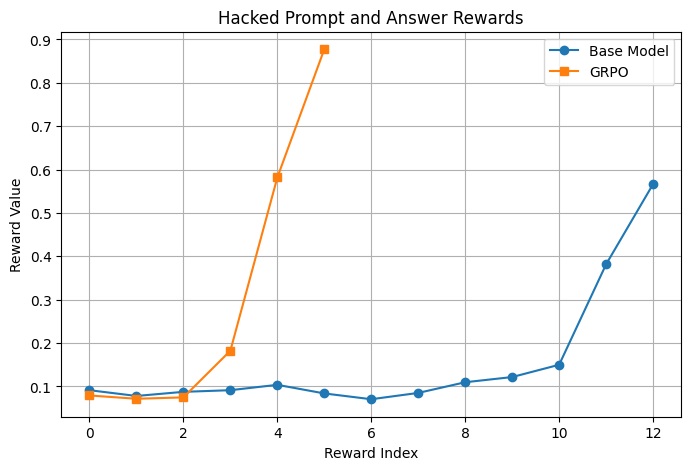

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(base_model_hacked_prompt_and_answer["rewards"], label="Base Model", marker='o')
plt.plot(grpo_hacked_prompt_and_answer["rewards"], label="GRPO", marker='s')
plt.title("Hacked Prompt and Answer Rewards")
plt.xlabel("Reward Index")
plt.ylabel("Reward Value")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
# Load model and tokenizer
path = "/data/atomar/.cache/huggingface/hub"
model_name = f"{path}/Skywork--Skywork-o1-Open-PRM-Qwen-2.5-1.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="cuda:0",
    trust_remote_code=True,
    use_safetensors=True,
)
model = model.eval()

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.00it/s]


In [10]:
def prepare_input(problem, response, tokenizer, step_token):
    prompt_ids = tokenizer.encode(tokenizer.bos_token + problem + "\n")
    response_ids = []
    steps = []
    reward_flags = [0] * len(prompt_ids)
    step_token_id = tokenizer.encode(step_token)[-1]
    for idx, step in enumerate(response.split(step_token)):
        if step != "":
            step_ids = tokenizer.encode(step)
        else:
            step_ids = []
        step_ids += [step_token_id]
        step = step + step_token
        flag = [0] * len(step_ids)
        flag[-1] = 1
        response_ids.extend(step_ids)
        reward_flags.extend(flag)
        steps.append(step)
    input_ids = prompt_ids + response_ids
    return input_ids, steps, reward_flags

def get_step_rewards(problem: str, response: str):
    input_ids, steps, reward_flags = prepare_input(problem, response, tokenizer, step_token="\n\n")
    inputs = torch.tensor([input_ids], device=model.device)
    
    with torch.no_grad():
        hidden_states = model.model(input_ids=inputs).last_hidden_state  
        
        batch_size, seq_len, hidden_dim = hidden_states.shape
        hidden_flat = hidden_states.view(-1, hidden_dim)  
        
        per_token_rewards = model.v_head.summary(model.v_head.dropout(hidden_flat))  
        per_token_rewards = per_token_rewards.view(seq_len)  
    
    step_rewards = [
        torch.sigmoid(per_token_rewards[i]).item()
        for i, flag in enumerate(reward_flags) if flag == 1
    ]
    
    return step_rewards

problem = grpo_hacked_prompt_and_answer["prompt"]
response = grpo_hacked_prompt_and_answer["answer"]

rewards = get_step_rewards(problem, response)
print(rewards)

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


[0.0791015625, 0.07177734375, 0.07470703125, 0.1796875, 0.58203125, 0.87890625]


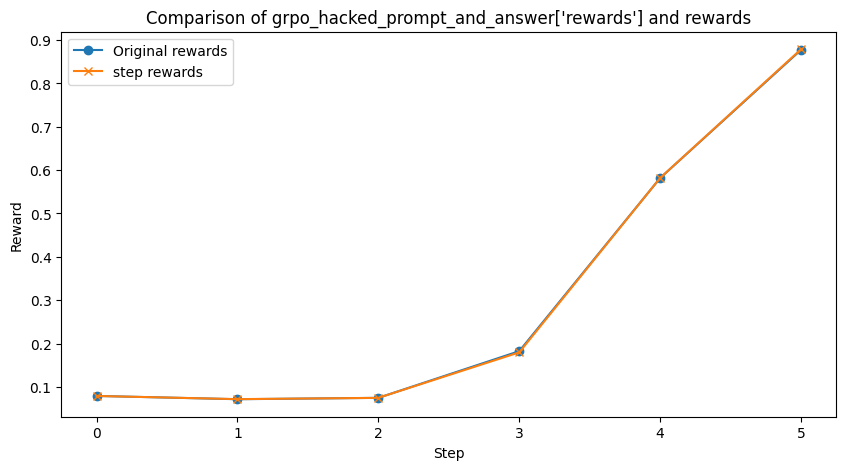

In [12]:
# just checking to make sure the rewards are the same as the one in the saved file
plt.figure(figsize=(10, 5))
plt.plot(grpo_hacked_prompt_and_answer["rewards"], label="Original rewards", marker='o')
plt.plot(rewards, label="step rewards", marker='x')
plt.xlabel("Step")
plt.ylabel("Reward")
plt.title("Comparison of grpo_hacked_prompt_and_answer['rewards'] and rewards")
plt.legend()
plt.show()


Running experiment for Base Model...


Sweeping epsilon: 100%|██████████| 10/10 [00:08<00:00,  1.24it/s]


Running experiment for GRPO Model...


Sweeping epsilon: 100%|██████████| 10/10 [00:05<00:00,  1.67it/s]


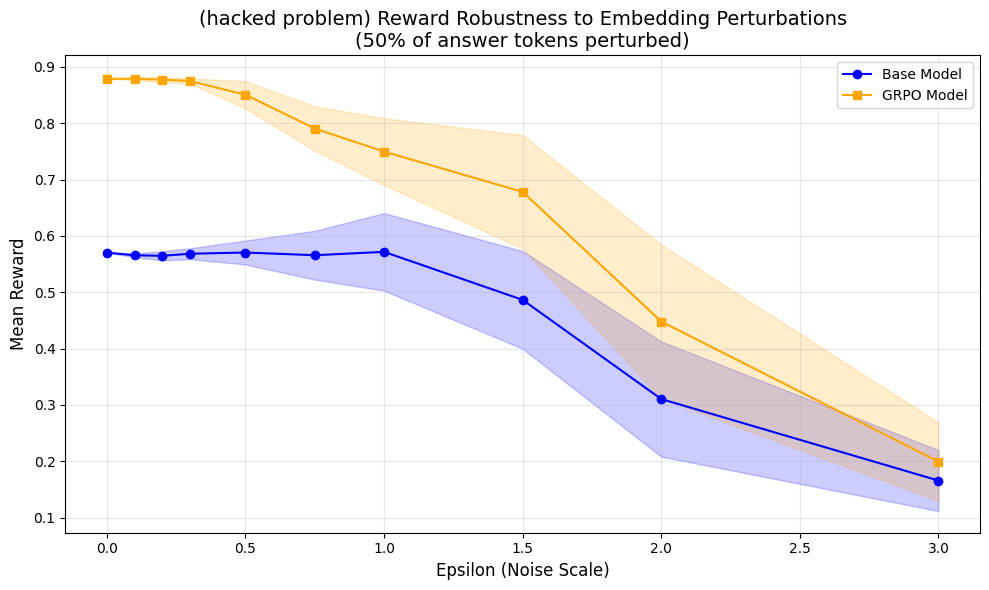


Numerical Results
Epsilon    Base Mean    Base Std     GRPO Mean    GRPO Std    
------------------------------------------------------------
0.00       0.1564       0.0000       0.3110       0.0000      
0.10       0.1555       0.0008       0.3109       0.0009      
0.20       0.1549       0.0017       0.3098       0.0013      
0.30       0.1540       0.0020       0.3083       0.0021      
0.50       0.1498       0.0047       0.2999       0.0060      
0.75       0.1411       0.0097       0.2704       0.0132      
1.00       0.1328       0.0135       0.2450       0.0215      
1.50       0.1289       0.0207       0.2019       0.0357      
2.00       0.1196       0.0209       0.1475       0.0305      
3.00       0.0977       0.0147       0.1076       0.0189      


In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def get_step_rewards_with_perturbation(
    problem: str, 
    response: str, 
    epsilon: float,
    perturb_fraction: float = 0.5,
    seed: int = None
):
    """
    Compute step rewards with perturbed embeddings.
    
    Args:
        problem: The prompt/question
        response: The model's answer
        epsilon: Noise scaling factor (noise magnitude = epsilon * ||embedding||)
        perturb_fraction: Fraction of answer tokens to perturb (default 0.5)
        seed: Random seed for reproducibility
    
    Returns:
        step_rewards: List of rewards per step
        mean_reward: Average of step rewards
    """
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
    
    input_ids, steps, reward_flags = prepare_input(problem, response, tokenizer, step_token="\n\n")
    
    # Identify prompt vs answer token boundaries
    prompt_text = tokenizer.bos_token + problem + "\n"
    prompt_ids = tokenizer.encode(prompt_text)
    prompt_len = len(prompt_ids)
    answer_len = len(input_ids) - prompt_len
    
    # Select 50% of answer token indices to perturb
    answer_indices = list(range(prompt_len, len(input_ids)))
    num_to_perturb = int(perturb_fraction * len(answer_indices))
    perturb_indices = set(np.random.choice(answer_indices, size=num_to_perturb, replace=False))
    
    inputs = torch.tensor([input_ids], device=model.device)
    
    with torch.no_grad():
        # Get embeddings from the embedding layer
        embeddings = model.model.embed_tokens(inputs)  # (1, seq_len, hidden_dim)
        
        # Create perturbed embeddings
        perturbed_embeddings = embeddings.clone()
        
        for idx in perturb_indices:
            emb = perturbed_embeddings[0, idx]  # (hidden_dim,)
            emb_norm = emb.norm()
            
            # Sample random Gaussian noise
            noise = torch.randn_like(emb)
            # Normalize noise to unit norm, then scale by epsilon * emb_norm
            noise = noise / noise.norm() * emb_norm * epsilon
            
            perturbed_embeddings[0, idx] = emb + noise
        
        # Forward pass through the rest of the model with perturbed embeddings
        # We need to bypass the embedding layer and pass embeddings directly
        hidden_states = model.model(
            inputs_embeds=perturbed_embeddings
        ).last_hidden_state
        
        batch_size, seq_len, hidden_dim = hidden_states.shape
        hidden_flat = hidden_states.view(-1, hidden_dim)
        
        per_token_rewards = model.v_head.summary(hidden_flat)
        per_token_rewards = per_token_rewards.view(seq_len)
    
    step_rewards = [
        torch.sigmoid(per_token_rewards[i]).item()
        for i, flag in enumerate(reward_flags) if flag == 1
    ]
    
    mean_reward = np.mean(step_rewards)
    
    return step_rewards, mean_reward


def run_perturbation_experiment(
    problem: str,
    response: str,
    epsilons: list,
    num_samples: int = 10,
    perturb_fraction: float = 0.5
):
    """
    Run perturbation experiment across multiple epsilon values.
    
    Args:
        problem: The prompt
        response: The answer
        epsilons: List of epsilon values to test
        num_samples: Number of noise samples per epsilon for averaging
        perturb_fraction: Fraction of answer tokens to perturb
    
    Returns:
        results: Dict with epsilon -> (mean_reward, std_reward)
    """
    results = {}
    
    for eps in tqdm(epsilons, desc="Sweeping epsilon"):
        rewards_at_eps = []
        all_rewards = {}
        for sample_idx in range(num_samples):
            step_rewards, mean_reward = get_step_rewards_with_perturbation(
                problem, response, 
                epsilon=eps, 
                perturb_fraction=perturb_fraction,
                seed=sample_idx
            )
            rewards_at_eps.append(mean_reward)
            all_rewards[sample_idx] = step_rewards
        
        # Average across samples for each step
        num_steps = len(all_rewards[0])
        all_rewards_averaged = [
            np.mean([all_rewards[j][i] for j in range(num_samples)])
            for i in range(num_steps)
        ]
        
        # Std across samples for each step
        all_rewards_std_per_step = [
            np.std([all_rewards[j][i] for j in range(num_samples)])
            for i in range(num_steps)
        ]
        
        # Final step statistics across samples
        final_step_rewards = [all_rewards[j][-1] for j in range(num_samples)]

        results[eps] = {
            'mean': np.mean(rewards_at_eps),
            'std': np.std(rewards_at_eps),
            'all_rewards': all_rewards_averaged,
            'all_rewards_std_per_step': all_rewards_std_per_step,
            'final_step_mean': np.mean(final_step_rewards),
            'final_step_std': np.std(final_step_rewards),
        }
    
    return results


# Also get baseline (no perturbation) rewards
def get_baseline_reward(problem: str, response: str):
    step_rewards = get_step_rewards(problem, response)
    return np.mean(step_rewards)


# Run experiments
epsilons = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
num_samples = 20

# Base model
print("Running experiment for Base Model...")
base_problem = base_model_hacked_prompt_and_answer["prompt"]
base_response = base_model_hacked_prompt_and_answer["answer"]
base_results = run_perturbation_experiment(base_problem, base_response, epsilons, num_samples)

# GRPO model
print("Running experiment for GRPO Model...")
grpo_problem = grpo_hacked_prompt_and_answer["prompt"]
grpo_response = grpo_hacked_prompt_and_answer["answer"]
grpo_results = run_perturbation_experiment(grpo_problem, grpo_response, epsilons, num_samples)


# Plot results
fig, ax = plt.subplots(figsize=(10, 6))

# Extract data for plotting
base_means = [base_results[eps]['final_step_mean'] for eps in epsilons]
base_stds = [base_results[eps]['final_step_std'] for eps in epsilons]
grpo_means = [grpo_results[eps]['final_step_mean'] for eps in epsilons]
grpo_stds = [grpo_results[eps]['final_step_std'] for eps in epsilons]

# Plot with error bands
ax.plot(epsilons, base_means, 'o-', label='Base Model', color='blue')
ax.fill_between(epsilons, 
                np.array(base_means) - np.array(base_stds),
                np.array(base_means) + np.array(base_stds),
                alpha=0.2, color='blue')

ax.plot(epsilons, grpo_means, 's-', label='GRPO Model', color='orange')
ax.fill_between(epsilons, 
                np.array(grpo_means) - np.array(grpo_stds),
                np.array(grpo_means) + np.array(grpo_stds),
                alpha=0.2, color='orange')

ax.set_xlabel('Epsilon (Noise Scale)', fontsize=12)
ax.set_ylabel('Mean Reward', fontsize=12)
ax.set_title('(hacked problem) Reward Robustness to Embedding Perturbations\n(50% of answer tokens perturbed)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print numerical results
print("\n" + "="*60)
print("Numerical Results")
print("="*60)
print(f"{'Epsilon':<10} {'Base Mean':<12} {'Base Std':<12} {'GRPO Mean':<12} {'GRPO Std':<12}")
print("-"*60)
for eps in epsilons:
    print(f"{eps:<10.2f} {base_results[eps]['mean']:<12.4f} {base_results[eps]['std']:<12.4f} "
          f"{grpo_results[eps]['mean']:<12.4f} {grpo_results[eps]['std']:<12.4f}")

Running experiment for Base Model...


Sweeping epsilon: 100%|██████████| 10/10 [00:07<00:00,  1.32it/s]


Running experiment for GRPO Model...


Sweeping epsilon: 100%|██████████| 10/10 [00:08<00:00,  1.12it/s]


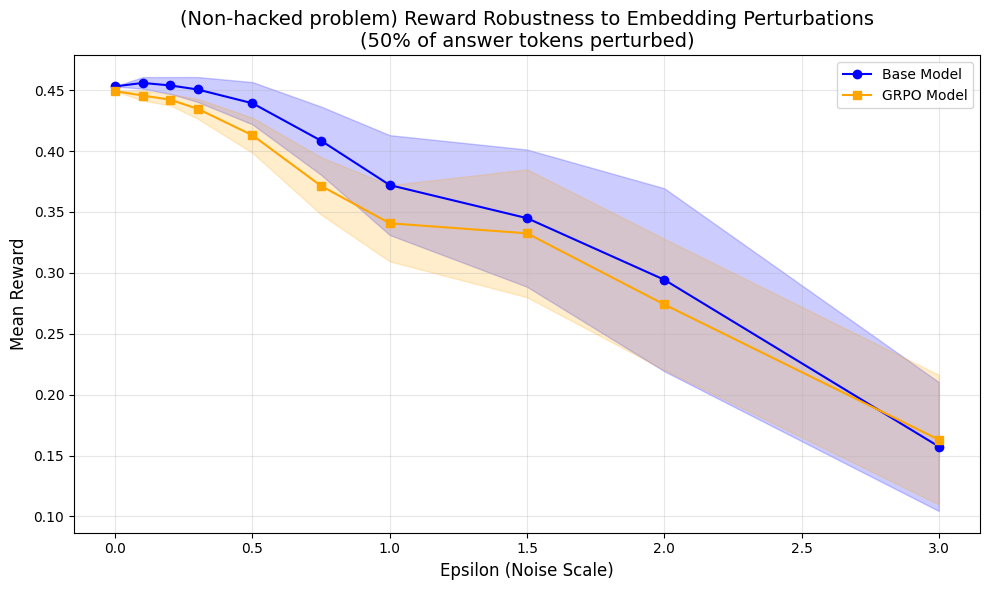


Numerical Results
Epsilon    Base Mean    Base Std     GRPO Mean    GRPO Std    
------------------------------------------------------------
0.00       0.2611       0.0000       0.1794       0.0000      
0.10       0.2623       0.0017       0.1790       0.0006      
0.20       0.2607       0.0026       0.1779       0.0012      
0.30       0.2583       0.0040       0.1754       0.0016      
0.50       0.2494       0.0069       0.1667       0.0026      
0.75       0.2227       0.0121       0.1485       0.0039      
1.00       0.1944       0.0142       0.1354       0.0092      
1.50       0.1720       0.0192       0.1219       0.0122      
2.00       0.1587       0.0238       0.1132       0.0130      
3.00       0.1115       0.0189       0.0905       0.0082      


In [45]:
# Run experiments
epsilons = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
num_samples = 20

# Base model
print("Running experiment for Base Model...")
base_problem = base_model_different_prompt_and_answer["prompt"]
base_response = base_model_different_prompt_and_answer["answer"]
base_results = run_perturbation_experiment(base_problem, base_response, epsilons, num_samples)

# GRPO model
print("Running experiment for GRPO Model...")
grpo_problem = grpo_trained_model_different_prompt_and_answer["prompt"]
grpo_response = grpo_trained_model_different_prompt_and_answer["answer"]
grpo_results = run_perturbation_experiment(grpo_problem, grpo_response, epsilons, num_samples)


# Plot results
fig, ax = plt.subplots(figsize=(10, 6))

# Extract data for plotting
base_means = [base_results[eps]['final_step_mean'] for eps in epsilons]
base_stds = [base_results[eps]['final_step_std'] for eps in epsilons]
grpo_means = [grpo_results[eps]['final_step_mean'] for eps in epsilons]
grpo_stds = [grpo_results[eps]['final_step_std'] for eps in epsilons]

# Plot with error bands
ax.plot(epsilons, base_means, 'o-', label='Base Model', color='blue')
ax.fill_between(epsilons, 
                np.array(base_means) - np.array(base_stds),
                np.array(base_means) + np.array(base_stds),
                alpha=0.2, color='blue')

ax.plot(epsilons, grpo_means, 's-', label='GRPO Model', color='orange')
ax.fill_between(epsilons, 
                np.array(grpo_means) - np.array(grpo_stds),
                np.array(grpo_means) + np.array(grpo_stds),
                alpha=0.2, color='orange')

ax.set_xlabel('Epsilon (Noise Scale)', fontsize=12)
ax.set_ylabel('Mean Reward', fontsize=12)
ax.set_title('(Non-hacked problem) Reward Robustness to Embedding Perturbations\n(50% of answer tokens perturbed)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print numerical results
print("\n" + "="*60)
print("Numerical Results")
print("="*60)
print(f"{'Epsilon':<10} {'Base Mean':<12} {'Base Std':<12} {'GRPO Mean':<12} {'GRPO Std':<12}")
print("-"*60)
for eps in epsilons:
    print(f"{eps:<10.2f} {base_results[eps]['mean']:<12.4f} {base_results[eps]['std']:<12.4f} "
          f"{grpo_results[eps]['mean']:<12.4f} {grpo_results[eps]['std']:<12.4f}")

Running experiment for Base Model...


Sweeping epsilon: 100%|██████████| 10/10 [00:08<00:00,  1.24it/s]


Running experiment for GRPO Model...


Sweeping epsilon: 100%|██████████| 10/10 [00:05<00:00,  1.67it/s]


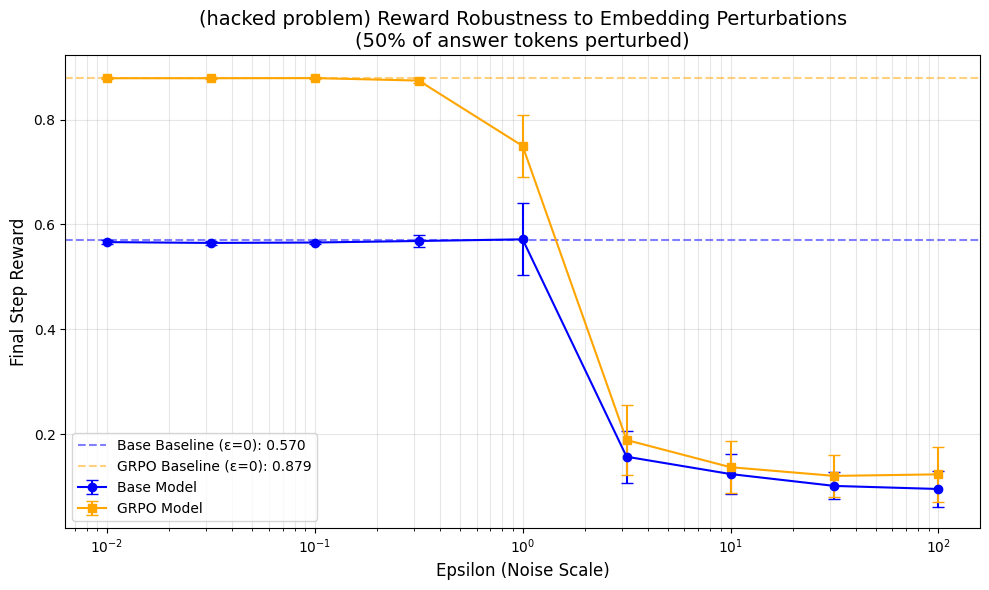


Numerical Results (Final Step Reward)
Epsilon        Base Mean    Base Std     GRPO Mean    GRPO Std    
----------------------------------------------------------------------
0 (baseline)   0.5703       0.0000       0.8789       0.0000      
1.00e-02       0.5664       0.0037       0.8787       0.0015      
3.16e-02       0.5648       0.0031       0.8787       0.0019      
1.00e-01       0.5656       0.0034       0.8789       0.0025      
3.16e-01       0.5686       0.0111       0.8742       0.0053      
1.00e+00       0.5717       0.0688       0.7496       0.0592      
3.16e+00       0.1574       0.0497       0.1893       0.0668      
1.00e+01       0.1244       0.0380       0.1375       0.0491      
3.16e+01       0.1018       0.0258       0.1209       0.0397      
1.00e+02       0.0959       0.0336       0.1239       0.0524      


In [47]:
# Sweep epsilon in log scale from 10^-2 to 10^2
epsilons = [0.0] + list(np.logspace(-2, 2, 9))  # 0 + 9 points from 1e-2 to 1e2
num_samples = 20

# Base model
print("Running experiment for Base Model...")
base_problem = base_model_hacked_prompt_and_answer["prompt"]
base_response = base_model_hacked_prompt_and_answer["answer"]
base_results = run_perturbation_experiment(base_problem, base_response, epsilons, num_samples)

# GRPO model
print("Running experiment for GRPO Model...")
grpo_problem = grpo_hacked_prompt_and_answer["prompt"]
grpo_response = grpo_hacked_prompt_and_answer["answer"]
grpo_results = run_perturbation_experiment(grpo_problem, grpo_response, epsilons, num_samples)


# Plot results with log scale on x-axis
fig, ax = plt.subplots(figsize=(10, 6))

base_means = [base_results[eps]['final_step_mean'] for eps in epsilons]
base_stds = [base_results[eps]['final_step_std'] for eps in epsilons]
grpo_means = [grpo_results[eps]['final_step_mean'] for eps in epsilons]
grpo_stds = [grpo_results[eps]['final_step_std'] for eps in epsilons]

# Separate epsilon=0 (baseline) from the log-scale points
eps_nonzero = epsilons[1:]
base_means_nonzero = base_means[1:]
base_stds_nonzero = base_stds[1:]
grpo_means_nonzero = grpo_means[1:]
grpo_stds_nonzero = grpo_stds[1:]

# Plot log-scale portion
ax.errorbar(eps_nonzero, base_means_nonzero, yerr=base_stds_nonzero,
            fmt='o-', label='Base Model', color='blue', capsize=4)
ax.errorbar(eps_nonzero, grpo_means_nonzero, yerr=grpo_stds_nonzero,
            fmt='s-', label='GRPO Model', color='orange', capsize=4)

# Add baseline (epsilon=0) as horizontal dashed lines
ax.axhline(y=base_means[0], color='blue', linestyle='--', alpha=0.5, label=f'Base Baseline (ε=0): {base_means[0]:.3f}')
ax.axhline(y=grpo_means[0], color='orange', linestyle='--', alpha=0.5, label=f'GRPO Baseline (ε=0): {grpo_means[0]:.3f}')

ax.set_xscale('log')
ax.set_xlabel('Epsilon (Noise Scale)', fontsize=12)
ax.set_ylabel('Final Step Reward', fontsize=12)
ax.set_title('(hacked problem) Reward Robustness to Embedding Perturbations\n(50% of answer tokens perturbed)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Print numerical results
print("\n" + "="*70)
print("Numerical Results (Final Step Reward)")
print("="*70)
print(f"{'Epsilon':<14} {'Base Mean':<12} {'Base Std':<12} {'GRPO Mean':<12} {'GRPO Std':<12}")
print("-"*70)
for eps in epsilons:
    eps_str = '0 (baseline)' if eps == 0 else f'{eps:.2e}'
    print(f"{eps_str:<14} {base_results[eps]['final_step_mean']:<12.4f} {base_results[eps]['final_step_std']:<12.4f} "
          f"{grpo_results[eps]['final_step_mean']:<12.4f} {grpo_results[eps]['final_step_std']:<12.4f}")